# Interactive plot for the functions:

$c: x^2+y^2+4x-12y+20=0$

$g(x)=2\sqrt{ax+b}$

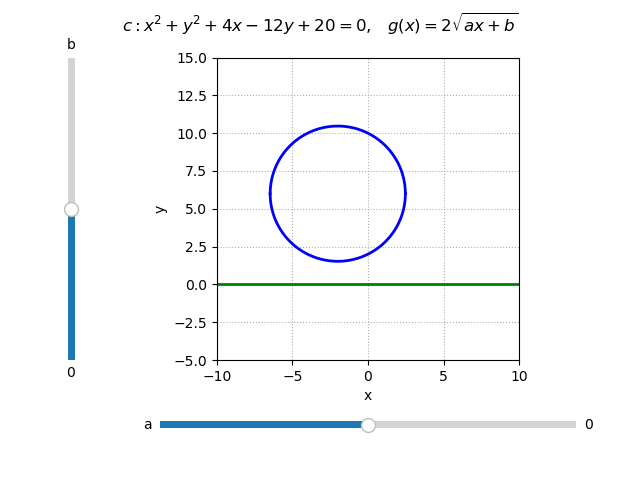

In [3]:
# IPython magic command for enabling interactive matplotlib plots in Jupyter
# notebook (disable when executing this code with a regular Python
# interpreter).
%matplotlib widget

# Imports
from matplotlib.widgets import Slider
import matplotlib.pyplot as plt
import numpy as np

# Parameters `x_c`, `x_g`, `a` and `b` have a static range
x_c_min = -2 - np.sqrt(20)
x_c_max = -2 + np.sqrt(20)
x_c = np.linspace(x_c_min, x_c_max, 1000)

x_g_min = -10
x_g_max = 10
x_g = np.linspace(x_g_min, x_g_max, 1000)

a_init = 0.0
a_min = -5.0
a_max = 5.0
a = np.linspace(a_min, a_max, 1000)

b_init = 0.0
b_min = -5.0
b_max = 5.0
b = np.linspace(b_min, b_max, 1000)

# `y` value for top half of circle `c`:
def func_ct(x):
    return 6 + np.sqrt(-x ** 2 - 4 * x +16)

# `y` value for bottom half of circle `c`:
def func_cb(x):
    return 6 - np.sqrt(-x ** 2 - 4 * x +16)

# `y` value for function `g(x)`:
def func_g(x, a, b):
    return 2 * np.sqrt(a * x + b)

# Latex string representation of functions
func_str = "$c: x^2+y^2+4x-12y+20=0$,   $g(x)=2\\sqrt{ax+b}$"

# Set axes limits
xlim = (x_g_min, x_g_max)
ylim = (-5, 15)

# Initialize figure with axes
fig = plt.figure()
axes = plt.axes(
    xlim=xlim,
    ylim=ylim,
)
axes.set_aspect("equal")
axes.grid(linestyle="dotted")
axes.set_xlabel("x")
axes.set_ylabel("y")

# Print equation of plotted function above axes
fig.suptitle(func_str)

# Expand figure window to make room for sliders
fig.subplots_adjust(left=0.25, bottom=0.25)

# Make a horizontal slider for `a`
axes_slider_a = fig.add_axes([0.25, 0.1, 0.65, 0.03])
slider_a = Slider(
    ax=axes_slider_a,
    label="a",
    valmin=a_min,
    valmax=a_max,
    valinit=a_init,
)

# Make a vertically oriented slider for `b`
axes_slider_b = fig.add_axes([0.1, 0.25, 0.0225, 0.63])
slider_b = Slider(
    ax=axes_slider_b,
    label="b",
    valmin=b_min,
    valmax=b_max,
    valinit=b_init,
    orientation="vertical"
)

# Initialize lines
yct_init = func_ct(x_c)
line_yct, = axes.plot(x_c, yct_init, lw = 2, color="b")
ycb_init = func_cb(x_c)
line_ycb, = axes.plot(x_c, ycb_init, lw = 2, color="b")
yg_init = func_g(x_g, a_init, b_init)
line_yg, = axes.plot(x_g, yg_init, lw = 2, color="g")

# Function for updating plot when a slider changes value
def update(_):
    a = slider_a.val
    b = slider_b.val
    y_ct = func_ct(x_c)
    y_cb = func_cb(x_c)
    y_g = func_g(x_g, a, b)
    line_yct.set_ydata(y_ct)
    line_ycb.set_ydata(y_cb)
    line_yg.set_ydata(y_g)
    fig.canvas.draw_idle()

# Link sliders to plot update function
slider_a.on_changed(update)
slider_b.on_changed(update)

# Show plot
plt.show()
